Mục tiêu: `Dataset Exploration`

Tạo thống kê: 
```
Class Distribution
Pixel Distribution
Sample Images
Dataset Summary
```

Sinh:
```
reports/

dataset_summary.json
class_distribution.png
sample_images.png
pixel_distribution.png
```

In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import MNIST

In [2]:
PROJECT_ROOT = Path("..").resolve()

RAW_DIR = PROJECT_ROOT / "raw"
REPORT_DIR = PROJECT_ROOT / "reports"

MNIST_DIR = RAW_DIR / "mnist"

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
validation_path = (
    REPORT_DIR /
    "validation.json"
)

with open(validation_path) as f:
    validation = json.load(f)

if not validation["overall_status"]:
    raise RuntimeError(
        "Dataset validation failed."
    )

print("Validation PASSED")

Validation PASSED


In [4]:
train_dataset = MNIST(
    root=str(MNIST_DIR),
    train=True,
    download=False
)

test_dataset = MNIST(
    root=str(MNIST_DIR),
    train=False,
    download=False
)

In [5]:
labels = train_dataset.targets.numpy()

summary = {
    "dataset": "MNIST",
    "train_samples": len(train_dataset),
    "test_samples": len(test_dataset),
    "image_height": 28,
    "image_width": 28,
    "channels": 1,
    "num_classes": len(np.unique(labels))
}

summary

{'dataset': 'MNIST',
 'train_samples': 60000,
 'test_samples': 10000,
 'image_height': 28,
 'image_width': 28,
 'channels': 1,
 'num_classes': 10}

In [6]:
unique, counts = np.unique(
    labels,
    return_counts=True
)

class_distribution = {
    str(k): int(v)
    for k, v in zip(unique, counts)
}

class_distribution

{'0': 5923,
 '1': 6742,
 '2': 5958,
 '3': 6131,
 '4': 5842,
 '5': 5421,
 '6': 5918,
 '7': 6265,
 '8': 5851,
 '9': 5949}

In [7]:
plt.figure(figsize=(10, 5))

plt.bar(
    unique,
    counts
)

plt.title(
    "MNIST Class Distribution"
)

plt.xlabel("Digit")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    REPORT_DIR /
    "class_distribution.png"
)

plt.close()

In [8]:
pixels = []

for image, _ in train_dataset:

    pixels.extend(
        np.array(image).flatten()
    )

In [9]:
pixels = np.array(pixels)

pixel_stats = {
    "pixel_min": int(pixels.min()),
    "pixel_max": int(pixels.max()),
    "pixel_mean": float(pixels.mean()),
    "pixel_std": float(pixels.std())
}

pixel_stats

{'pixel_min': 0,
 'pixel_max': 255,
 'pixel_mean': 33.318421449829934,
 'pixel_std': 78.56748998339798}

In [10]:
plt.figure(figsize=(10,5))

plt.hist(
    pixels,
    bins=50
)

plt.title(
    "Pixel Value Distribution"
)

plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    REPORT_DIR /
    "pixel_distribution.png"
)

plt.close()

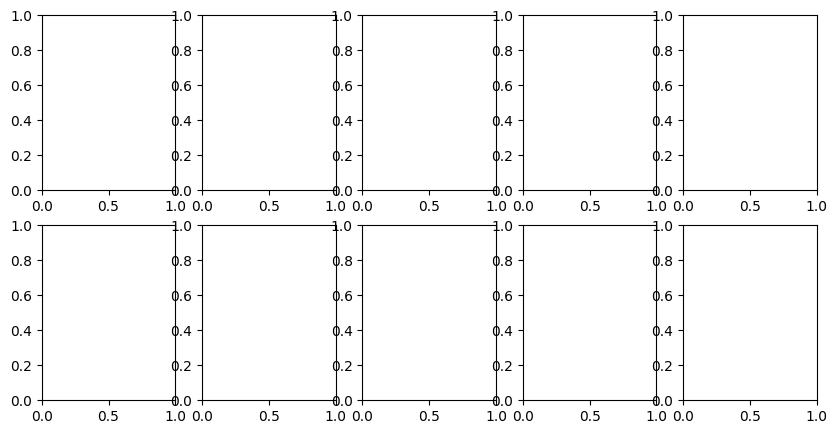

In [11]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(10,5)
)

In [12]:
for ax, idx in zip(
    axes.ravel(),
    range(10)
):

    image, label = train_dataset[idx]

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.set_title(
        f"Label {label}"
    )

    ax.axis("off")

In [14]:
dataset_summary = {
    **summary,
    **pixel_stats,
    "class_distribution": class_distribution
}

In [15]:
with open(
    REPORT_DIR /
    "dataset_summary.json",
    "w"
) as f:

    json.dump(
        dataset_summary,
        f,
        indent=4
    )

In [ ]:
dataset_card = f"""
# Dataset Card

## Dataset

MNIST

---

## Overview

Handwritten digit classification dataset.

---

## Statistics

| Metric | Value |
|----------|----------|
| Train Samples | {summary['train_samples']} |
| Test Samples | {summary['test_samples']} |
| Classes | {summary['num_classes']} |
| Image Size | 28 x 28 |
| Channels | 1 |

---

## Pixel Statistics

| Metric | Value |
|----------|----------|
| Min | {pixel_stats['pixel_min']} |
| Max | {pixel_stats['pixel_max']} |
| Mean | {pixel_stats['pixel_mean']:.4f} |
| Std | {pixel_stats['pixel_std']:.4f} |

---

## Label Distribution

Stored in:

- class_distribution.png

---

## Example Images

Stored in:

- sample_images.png
"""

In [17]:
with open(
    REPORT_DIR /
    "dataset_card.md",
    "w"
) as f:

    f.write(dataset_card)